# 1.2 ML Model
Reads the processed CSVs from the ETL, trains a Logistic Regression pipeline, evaluates it, and exports the model as a `.joblib` file for the Streamlit web app.

In [84]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection   import train_test_split, TimeSeriesSplit
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.pipeline          import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.metrics           import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Paths ──────────────────────────────────────────────────────────
PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../my-repo/models"
os.makedirs(MODELS_DIR, exist_ok=True)

FEATURE_COLS = [
    "Returns", "SMA_5", "SMA_20",
    "Volatility_5", "Volatility_20",
    "Volume_Change", "RSI_14", "Price_Range"
]
TARGET = "Target"

## Step 1 — Load ETL output
Do NOT re-run ETL here. Just read the CSV the ETL already saved.

In [85]:
TICKER = "AMZN"  # start with one ticker, then loop over all

df = pd.read_csv(f"{PROCESSED_DIR}/{TICKER.lower()}_processed.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Drop the last row — it has NaN target (no tomorrow)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df[TARGET].value_counts())
df.head()

Shape: (1218, 19)

Target distribution:
Target
1.0    628
0.0    590
Name: count, dtype: int64


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Shares Outstanding,Returns,SMA_5,SMA_20,Volatility_5,Volatility_20,Volume_Change,RSI_14,Price_Range,Target
0,AMZN,62747,2020-05-06,116.47,117.87,116.00,117.56,117.56,62356280,9.975521e+09,0.014307,117.450,115.8285,0.045687,0.031274,-0.038452,45.977985,0.015907,1.0
1,AMZN,62747,2020-05-07,118.74,118.80,117.16,118.38,118.38,67928220,9.975521e+09,0.006951,116.386,116.6400,0.039634,0.031221,0.089357,49.465163,0.013854,1.0
2,AMZN,62747,2020-05-08,118.61,119.36,117.85,118.98,118.98,64224560,9.975521e+09,0.005056,117.322,117.4820,0.005637,0.031178,-0.054523,48.978400,0.012691,1.0
3,AMZN,62747,2020-05-11,118.73,120.98,118.61,120.45,120.45,65184620,9.975521e+09,0.012279,118.252,118.0825,0.005476,0.028700,0.014948,56.223044,0.019676,0.0
4,AMZN,62747,2020-05-12,120.59,120.95,117.75,117.85,117.85,61498320,9.975521e+09,-0.021822,118.644,118.2665,0.014571,0.027122,-0.056552,49.519520,0.027153,1.0


## Step 2 — Train / Test / Reserved split
- **10%** reserved — never touched during training or evaluation
- **60%** of remainder → train
- **40%** of remainder → test

`shuffle=False` preserves chronological order (critical for time series data).

In [86]:
# Hold out 10% as reserved (final sanity check only — never used for fitting)
df_model, df_reserved = train_test_split(
    df,
    test_size=0.1,
    shuffle=False,   # keep time order
    random_state=42
)

X_model = df_model[FEATURE_COLS]
y_model = df_model[TARGET]

# Split remaining 90% into train (60%) and test (40%)
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size=0.4,
    shuffle=False,
    random_state=42
)

print(f"Train:    {X_train.shape}")
print(f"Test:     {X_test.shape}")
print(f"Reserved: {df_reserved.shape}")

Train:    (657, 8)
Test:     (439, 8)
Reserved: (122, 19)


## Step 3 — Correlation heatmap
Look for pairs of features with |r| >= 0.5 — these may be multicollinear.

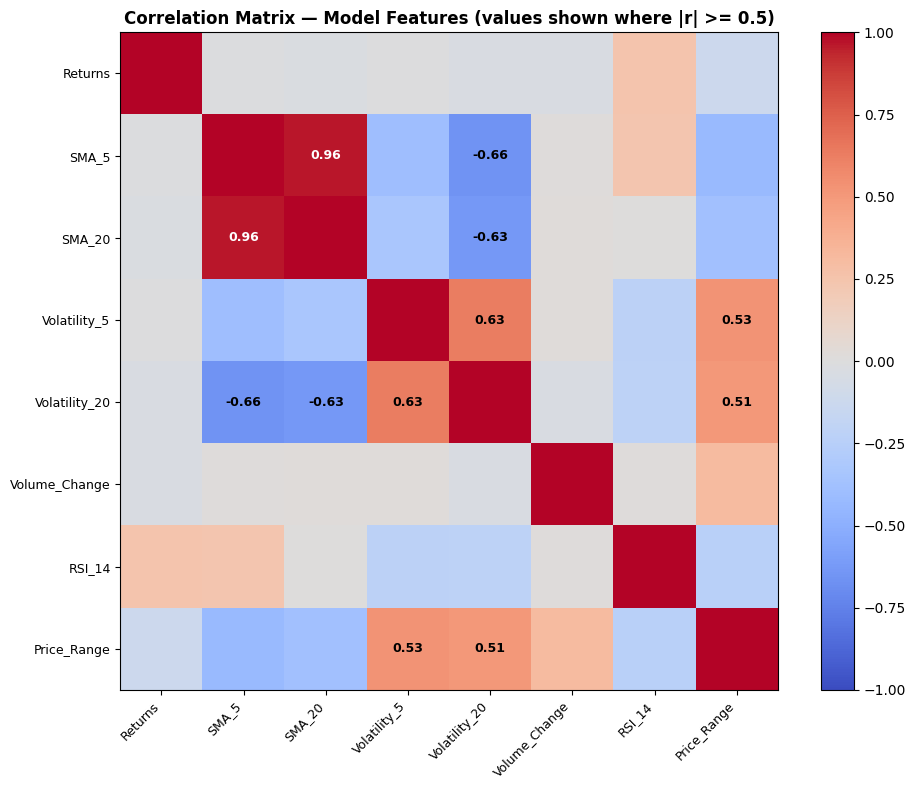

In [87]:
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Annotate only strong correlations
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.5 and i != j:
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if abs(val) > 0.8 else "black",
                    fontsize=9, fontweight="bold")

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=9)
plt.colorbar(cax)
ax.set_title("Correlation Matrix — Model Features (values shown where |r| >= 0.5)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 4 — VIF Analysis
Variance Inflation Factor measures multicollinearity.
- VIF > 10 → serious problem, drop that feature
- We drop one at a time (the worst) and recompute until all VIF <= 10

The loop below prints every iteration so you can see exactly what is happening.

In [88]:
def compute_vif(X_df: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for each feature. Higher = more multicollinear."""
    vif = pd.DataFrame()
    vif["Variable"] = X_df.columns
    vif["VIF"]      = [variance_inflation_factor(X_df.values, i)
                       for i in range(X_df.shape[1])]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)


X_vif     = X_train.copy()
iteration = 1

print("=" * 60)
print("VIF ANALYSIS — drop features with VIF > 10 one at a time")
print("=" * 60)

while True:
    vif_table = compute_vif(X_vif)
    max_vif   = vif_table.iloc[0]["VIF"]
    worst_var = vif_table.iloc[0]["Variable"]

    print(f"\n--- Iteration {iteration} | {X_vif.shape[1]} features remaining ---")
    print(vif_table.to_string(index=False))

    if max_vif <= 10:
        print(f"\n✔  All VIF <= 10 — stopping.")
        print(f"✔  Final feature set: {list(X_vif.columns)}")
        break

    print(f"\n  ⚠  Dropping '{worst_var}'  (VIF = {max_vif:.2f} > 10)")
    X_vif = X_vif.drop(columns=[worst_var])
    iteration += 1

X_after_vif       = X_vif.copy()
selected_vif_cols = X_after_vif.columns.tolist()
print(f"\nFeatures after VIF ({len(selected_vif_cols)}): {selected_vif_cols}")

VIF ANALYSIS — drop features with VIF > 10 one at a time

--- Iteration 1 | 8 features remaining ---
     Variable         VIF
        SMA_5 2116.947699
       SMA_20 1845.992721
       RSI_14   32.516761
Volatility_20   12.123180
  Price_Range    8.841419
 Volatility_5    7.139746
Volume_Change    1.201706
      Returns    1.171483

  ⚠  Dropping 'SMA_5'  (VIF = 2116.95 > 10)

--- Iteration 2 | 7 features remaining ---
     Variable       VIF
       SMA_20 11.960726
Volatility_20 11.322024
       RSI_14  9.775748
  Price_Range  8.577759
 Volatility_5  7.116856
Volume_Change  1.200542
      Returns  1.083812

  ⚠  Dropping 'SMA_20'  (VIF = 11.96 > 10)

--- Iteration 3 | 6 features remaining ---
     Variable       VIF
Volatility_20 11.260887
  Price_Range  8.265865
 Volatility_5  7.051967
       RSI_14  3.978780
Volume_Change  1.197027
      Returns  1.054922

  ⚠  Dropping 'Volatility_20'  (VIF = 11.26 > 10)

--- Iteration 4 | 5 features remaining ---
     Variable      VIF
  Price_Ra

## Step 5 — RFECV Feature Selection
Recursive Feature Elimination with Cross-Validation automatically finds the number of features that maximises AUC.

`TimeSeriesSplit` is used instead of regular KFold because stock data is a time series — shuffling folds would leak future data into training.

Optimal number of features: 3

Selected features:
  ✔  Returns
  ✔  Volume_Change
  ✔  Price_Range

Dropped by RFECV:
  ✗  Volatility_5
  ✗  RSI_14


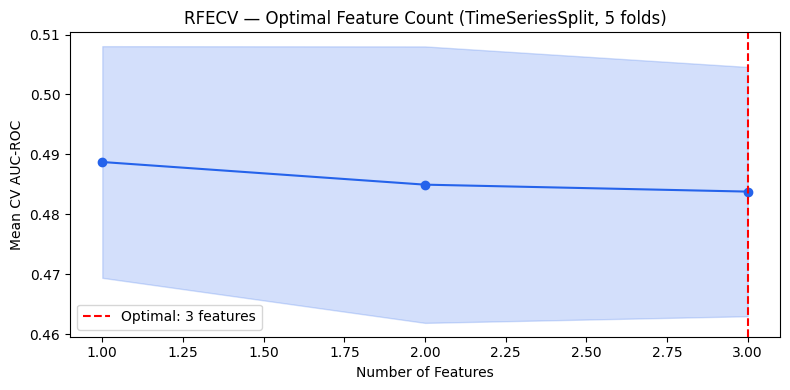

In [89]:
# Prepare matrices from VIF-selected columns only
X_train_vif = X_train[selected_vif_cols].dropna()
y_train_vif = y_train.loc[X_train_vif.index]

X_test_vif  = X_test[selected_vif_cols].dropna()
y_test_vif  = y_test.loc[X_test_vif.index]

# Scale on training data only (prevent leakage)
scaler_rfe     = StandardScaler()
X_train_scaled = scaler_rfe.fit_transform(X_train_vif)
X_test_scaled  = scaler_rfe.transform(X_test_vif)

# RFECV
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    step=1,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="roc_auc",
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(X_train_scaled, y_train_vif)

feature_names     = X_train_vif.columns.tolist()
selected_features = [f for f, s in zip(feature_names, rfecv.support_) if s]
dropped_features  = [f for f, s in zip(feature_names, rfecv.support_) if not s]

print(f"Optimal number of features: {rfecv.n_features_}")
print("\nSelected features:")
for f in selected_features:
    print(f"  ✔  {f}")
print("\nDropped by RFECV:")
for f in dropped_features:
    print(f"  ✗  {f}")

# Plot AUC vs number of features
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"], marker="o", color="#2563EB")
plt.fill_between(
    range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
    rfecv.cv_results_["mean_test_score"] - rfecv.cv_results_["std_test_score"],
    rfecv.cv_results_["mean_test_score"] + rfecv.cv_results_["std_test_score"],
    alpha=0.2, color="#2563EB"
)
plt.axvline(rfecv.n_features_, color="red", linestyle="--",
            label=f"Optimal: {rfecv.n_features_} features")
plt.xlabel("Number of Features")
plt.ylabel("Mean CV AUC-ROC")
plt.title("RFECV — Optimal Feature Count (TimeSeriesSplit, 5 folds)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 — Train the Pipeline
A Pipeline chains StandardScaler and LogisticRegression together.
This ensures scaling is always applied consistently when calling predict().

In [90]:
X_train_sel = X_train[selected_features].dropna()
y_train_sel = y_train.loc[X_train_sel.index]

X_test_sel  = X_test[selected_features].dropna()
y_test_sel  = y_test.loc[X_test_sel.index]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train_sel, y_train_sel)
print(f"Model trained on {len(selected_features)} features: {selected_features}")

Model trained on 3 features: ['Returns', 'Volume_Change', 'Price_Range']


## Step 7 — Confusion Matrix & Classification Report

              precision    recall  f1-score   support

    Fall (0)       0.40      0.28      0.33       207
    Rise (1)       0.49      0.63      0.55       232

    accuracy                           0.46       439
   macro avg       0.45      0.45      0.44       439
weighted avg       0.45      0.46      0.45       439



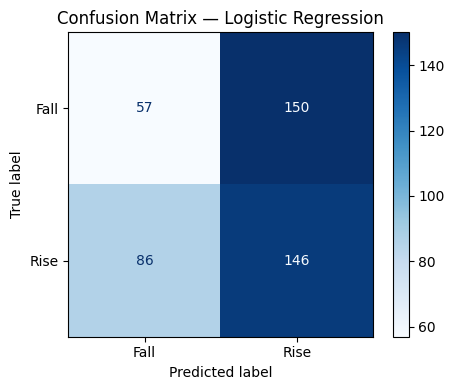

In [91]:
y_pred = pipe.predict(X_test_sel)

print(classification_report(y_test_sel, y_pred,
      target_names=["Fall (0)", "Rise (1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_sel, y_pred,
    display_labels=["Fall", "Rise"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

## Step 8 — ROC Curve & AUC

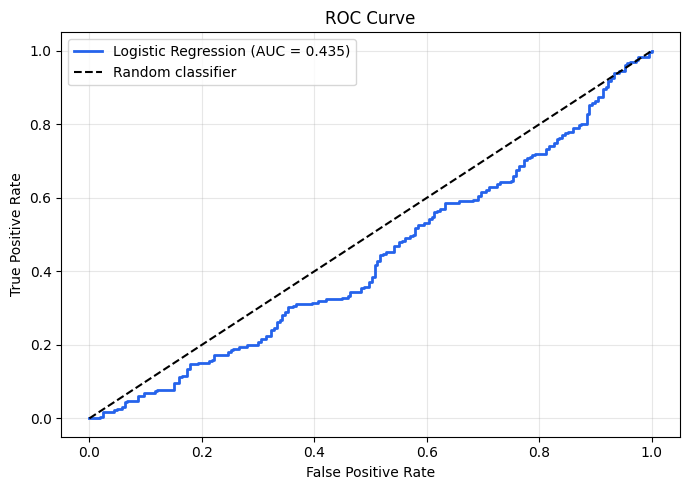

AUC Score: 0.4351


In [92]:
y_proba = pipe.predict_proba(X_test_sel)[:, 1]
fpr, tpr, _ = roc_curve(y_test_sel, y_proba)
auc = roc_auc_score(y_test_sel, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})",
         color="#2563EB", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

## Step 9 — Threshold Analysis
The default threshold of 0.5 is not always optimal.
Sweep from 0.1 to 0.9 and find the threshold that maximises F1.

 Threshold  Accuracy  Precision  Recall    F1  TP  FP  TN  FN
      0.10     0.528      0.528   1.000 0.692 232 207   0   0
      0.15     0.528      0.528   1.000 0.692 232 207   0   0
      0.20     0.528      0.528   1.000 0.692 232 207   0   0
      0.25     0.528      0.528   1.000 0.692 232 207   0   0
      0.30     0.528      0.528   1.000 0.692 232 207   0   0
      0.35     0.528      0.528   1.000 0.692 232 207   0   0
      0.40     0.528      0.528   1.000 0.692 232 207   0   0
      0.45     0.524      0.527   0.983 0.686 228 205   2   4
      0.50     0.462      0.493   0.629 0.553 146 150  57  86
      0.55     0.456      0.419   0.078 0.131  18  25 182 214
      0.60     0.462      0.167   0.004 0.008   1   5 202 231
      0.65     0.472      0.000   0.000 0.000   0   0 207 232
      0.70     0.472      0.000   0.000 0.000   0   0 207 232
      0.75     0.472      0.000   0.000 0.000   0   0 207 232
      0.80     0.472      0.000   0.000 0.000   0   0 207 232
      0.

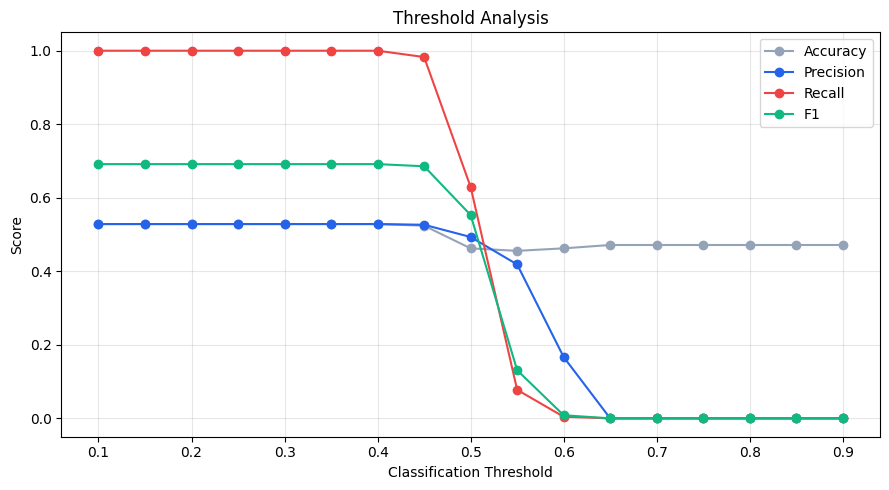


Best threshold by F1: 0.1
Threshold      0.100000
Accuracy       0.528474
Precision      0.528474
Recall         1.000000
F1             0.691505
TP           232.000000
FP           207.000000
TN             0.000000
FN             0.000000
Name: 0, dtype: float64


In [93]:
results = []
for thr in np.arange(0.1, 0.91, 0.05):
    y_pred_t = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_sel, y_pred_t).ravel()
    results.append({
        "Threshold": round(thr, 2),
        "Accuracy":  accuracy_score(y_test_sel, y_pred_t),
        "Precision": precision_score(y_test_sel, y_pred_t, zero_division=0),
        "Recall":    recall_score(y_test_sel, y_pred_t, zero_division=0),
        "F1":        f1_score(y_test_sel, y_pred_t, zero_division=0),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.round(3).to_string(index=False))

# Plot
plt.figure(figsize=(9, 5))
for metric, color in [("Accuracy","#94a3b8"),("Precision","#2563EB"),
                       ("Recall","#ef4444"),("F1","#10b981")]:
    plt.plot(threshold_df["Threshold"], threshold_df[metric],
             marker="o", label=metric, color=color)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
print(f"\nBest threshold by F1: {best_row['Threshold']}")
print(best_row)

## Step 10 — Export the model
Saves the trained pipeline and selected feature list.
The Streamlit web app loads these two files at runtime.

In [94]:
model_path    = os.path.join(MODELS_DIR, f"model_{TICKER}.joblib")
features_path = os.path.join(MODELS_DIR, f"features_{TICKER}.txt")

joblib.dump(pipe, model_path)

with open(features_path, "w") as f:
    f.write("\n".join(selected_features))

print(f"✔  Model saved    → {model_path}")
print(f"✔  Features saved → {features_path}")

✔  Model saved    → ../my-repo/models/model_AMZN.joblib
✔  Features saved → ../my-repo/models/features_AMZN.txt


## Step 11 — Scale to all tickers
Run the full pipeline for each ticker in one loop.
Make sure the ETL has already been run for all tickers before this cell.

In [95]:
def train_and_save(ticker: str) -> dict:
    """Full ML pipeline for one ticker. Returns AUC score."""
    df = pd.read_csv(f"{PROCESSED_DIR}/{ticker.lower()}_processed.csv",
                     parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)

    df_model, _ = train_test_split(df, test_size=0.1,
                                   shuffle=False, random_state=42)
    X = df_model[FEATURE_COLS]
    y = df_model[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, shuffle=False, random_state=42)

    # VIF
    X_vif = X_train.dropna().copy()
    while True:
        vif_table = compute_vif(X_vif)
        if vif_table.iloc[0]["VIF"] <= 10:
            break
        X_vif = X_vif.drop(columns=[vif_table.iloc[0]["Variable"]])
    vif_cols = X_vif.columns.tolist()

    # RFECV
    X_tr = X_train[vif_cols].dropna()
    y_tr = y_train.loc[X_tr.index]
    X_te = X_test[vif_cols].dropna()
    y_te = y_test.loc[X_te.index]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    rfe = RFECV(LogisticRegression(max_iter=1000, random_state=42),
                step=1, cv=TimeSeriesSplit(n_splits=5),
                scoring="roc_auc", min_features_to_select=3, n_jobs=-1)
    rfe.fit(X_tr_s, y_tr)
    feats = [f for f, s in zip(vif_cols, rfe.support_) if s]

    # Train pipeline
    pipe_t = Pipeline([("scaler", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=1000, random_state=42))])
    pipe_t.fit(X_tr[feats], y_tr)
    auc = roc_auc_score(y_te, pipe_t.predict_proba(X_te[feats])[:, 1])

    # Save
    joblib.dump(pipe_t, f"{MODELS_DIR}/model_{ticker}.joblib")
    with open(f"{MODELS_DIR}/features_{ticker}.txt", "w") as f:
        f.write("\n".join(feats))

    print(f"{ticker:6s}  AUC = {auc:.3f}  features = {feats}")
    return {"ticker": ticker, "auc": round(auc, 4), "features": feats}


TICKERS = ["AMZN", "AAPL", "MSFT", "GOOG", "TSLA"]
summary = [train_and_save(t) for t in TICKERS]
pd.DataFrame(summary).set_index("ticker")

AMZN    AUC = 0.435  features = ['Returns', 'Volume_Change', 'Price_Range']
AAPL    AUC = 0.477  features = ['Returns', 'Volatility_5', 'RSI_14', 'Price_Range']
MSFT    AUC = 0.513  features = ['Volatility_5', 'RSI_14', 'Price_Range']
GOOG    AUC = 0.480  features = ['Returns', 'SMA_20', 'Volatility_5', 'Volume_Change', 'RSI_14', 'Price_Range']
TSLA    AUC = 0.580  features = ['Returns', 'SMA_20', 'RSI_14']


,auc,features
ticker,,
AMZN,0.4351,"[Returns, Volume_Change, Price_Range]"
AAPL,0.4767,"[Returns, Volatility_5, RSI_14, Price_Range]"
MSFT,0.5130,"[Volatility_5, RSI_14, Price_Range]"
GOOG,0.4796,"[Returns, SMA_20, Volatility_5, Volume_Change,..."
TSLA,0.5802,"[Returns, SMA_20, RSI_14]"


In [96]:
import os

os.listdir("../models")

['model_AMZN.joblib',
 'model_AAPL.joblib',
 'features_MSFT.txt',
 'features_AMZN.txt',
 'heatmap_AMZN.png',
 'model_MSFT.joblib',
 'model_GOOG.joblib',
 'features_AAPL.txt',
 'features_GOOG.txt',
 'model_TSLA.joblib',
 'features_TSLA.txt']

In [97]:
import joblib
import pandas as pd

ticker = "AAPL"

df = pd.read_csv(f"../data/processed/{ticker.lower()}_processed.csv")

model = joblib.load(f"../my-repo/models/model_{ticker}.joblib")

with open(f"../my-repo/models/features_{ticker}.txt") as f:
    feats = [line.strip() for line in f]

X = df[feats].dropna()

pred = model.predict(X.tail(1))

print("Prediction:", pred)

Prediction: [1.]
